# Hybrid A* — plan once

Debug notebook: call the pybind `hybrid_astar` module, plan once, and visualize the **rear-axle** trajectory .

Build first:
```bash
cd build && cmake .. && make -j
```
Module output: `build/python/hybrid_astar*.so`


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

ROOT = Path.cwd
if not (ROOT / "build").exists and (ROOT.parent / "build").exists:
  ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "build" / "python"))
sys.path.insert(0, str(ROOT / "build"))

import hybrid_astar

print("vehicle L/W/R =", hybrid_astar.vehicle_length, hybrid_astar.vehicle_width, hybrid_astar.min_turning_radius)
print("module:", hybrid_astar.__file__)

vehicle L/W/R = 4.933 2.11 4.5959343910217285
module: /home/jamie/source_codes/hybrid_astar_algorithm/build/python/hybrid_astar.cpython-310-x86_64-linux-gnu.so


In [2]:
def pose_to_box(x, y, theta, length, width, center_to_geometry_center, **kwargs):
  """Vehicle rectangle from rear-axle pose (x, y, theta)."""
  c, s = np.cos(theta), np.sin(theta)
  cx = x + center_to_geometry_center * c
  cy = y + center_to_geometry_center * s
  corners = np.array([
    [ length / 2, width / 2],
    [-length / 2, width / 2],
    [-length / 2, -width / 2],
    [ length / 2, -width / 2],
  ])
  rot = np.array([[c, -s], [s, c]])
  world = corners @ rot.T + np.array([cx, cy])
  return patches.Polygon(world, closed=True, **kwargs)


def plot_path(ax, path, color, label, length, width, d_cg, draw_cars=True):
  pts = np.asarray(path, dtype=float)
  if pts.size == 0:
    print(f"{label}: empty path")
    return
  ax.plot(pts[:, 0], pts[:, 1], "-o", color=color, ms=3, label=label)
  if draw_cars:
    for x, y, t in pts[:: max(1, len(pts) // 8)]:
      ax.add_patch(pose_to_box(
        x, y, t, length, width, d_cg,
        fill=False, edgecolor=color, linewidth=0.8, alpha=0.5))


def plan_once(start, goal, width=20, height=20, occupancy=None, show_smoothed=True):
  planner = hybrid_astar.Planner
  result = planner.plan(
    start_x=float(start[0]), start_y=float(start[1]), start_t=float(start[2]),
    goal_x=float(goal[0]), goal_y=float(goal[1]), goal_t=float(goal[2]),
    width=int(width), height=int(height),
    occupancy=occupancy,
  )

  L = hybrid_astar.vehicle_length
  W = hybrid_astar.vehicle_width
  d_cg = hybrid_astar.center_to_geometry_center

  fig, ax = plt.subplots(figsize=(8, 8))
  if occupancy is not None:
    ax.imshow(occupancy, origin="lower", cmap="Greys", alpha=0.4,
         extent=[0, width, 0, height])

  plot_path(ax, result.path, "C0", "path (rear axle)", L, W, d_cg)
  if show_smoothed:
    plot_path(ax, result.smoothed_path, "C2", "smoothed", L, W, d_cg, draw_cars=False)

  ax.add_patch(pose_to_box(*start, L, W, d_cg, fill=False, edgecolor="blue", linewidth=2, label="start"))
  ax.add_patch(pose_to_box(*goal, L, W, d_cg, fill=False, edgecolor="green", linewidth=2, label="goal"))
  ax.plot(start[0], start[1], "b+", ms=12)
  ax.plot(goal[0], goal[1], "g+", ms=12)

  ax.set_aspect("equal")
  ax.set_xlim(0, width)
  ax.set_ylim(0, height)
  ax.grid(True, alpha=0.3)
  ax.legend(loc="best")
  ax.set_title("Hybrid A* (rear-axle pose)")
  plt.show

  print(f"path points: {len(result.path)}, smoothed: {len(result.smoothed_path)}")
  return result


## Case 1 — free space straight-ish

I am building the collision lookup table... done!
I am building the collision lookup table... done!


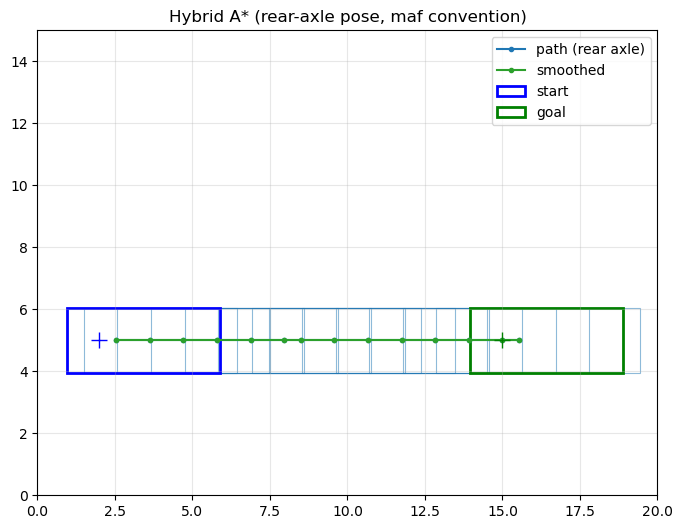

path points: 14, smoothed: 14


In [3]:
start = (2.0, 5.0, 0.0)
goal = (15.0, 5.0, 0.0)
result = plan_once(start, goal, width=20, height=15)

## Case 2 — change heading (parallel park style pose change)

I am building the collision lookup table... done!
I am building the collision lookup table... done!


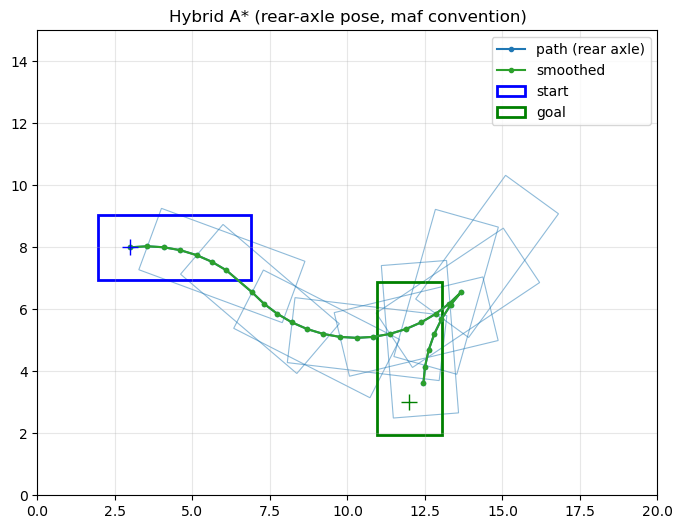

path points: 28, smoothed: 28


In [4]:
start = (3.0, 8.0, 0.0)
goal = (12.0, 3.0, np.deg2rad(90))
result = plan_once(start, goal, width=20, height=15)

## Case 3 — heading change with larger map

Occupancy maps are not wired yet (`CollisionDetection` is null; `setMap` deferred). Use free-space cases for now.

I am building the collision lookup table... done!
I am building the collision lookup table... done!


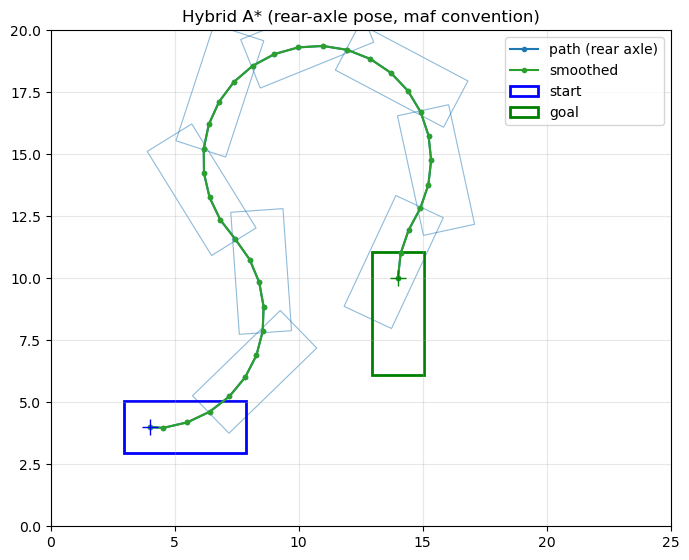

path points: 35, smoothed: 35
last pose: [14.000007629394531, 10.008601188659668, 4.710517406463623]


In [5]:
start = (4.0, 4.0, np.deg2rad(0))
goal = (14.0, 10.0, np.deg2rad(-90))
result = plan_once(start, goal, width=25, height=20)
print("last pose:", result.path[-1] if result.path else None)

## Case from a folder

Files may be:
1. **Full ODO** (yaml/json): `init_state`, `target_state`, `map_boundary`, obstacles — openspace ODO format.
2. **Search result trajectory** (`x/y/phi/v/...`): synthesize a minimal ODO from start/end poses and AABB, keep the trajectory as reference for overlay.


In [18]:
from pathlib import Path
import json
import math

try:
  import yaml
except ImportError:
  yaml = None


DATA_DIR = Path("~/source_codes/openspace_benchmark/apa_normal/zhaorun").expanduser


def _load_raw(path):
  path = Path(path).expanduser.resolve
  text = path.read_text
  if path.suffix.lower in {".yaml", ".yml"}:
    if yaml is None:
      raise ImportError("PyYAML required for yaml cases: pip install pyyaml")
    return yaml.safe_load(text)
  return json.loads(text)


def _pose_from_init_target(state):
  """TrajectoryPoint yaml/json → (x, y, theta)."""
  pp = state["path_point"]
  if isinstance(pp, dict):
    return float(pp["x"]), float(pp["y"]), float(pp.get("theta", pp.get("phi", 0.0)))
  return float(pp[0]), float(pp[1]), float(pp[2])


def is_odo(data: dict) -> bool:
  return isinstance(data, dict) and "init_state" in data and "target_state" in data and "map_boundary" in data


def is_sbp_result(data: dict) -> bool:
  return isinstance(data, dict) and all(k in data for k in ("x", "y", "phi"))


def extract_odo(data: dict, margin: float = 8.0) -> dict:
  """Extract / synthesize OpenspaceDeciderOutput-like dict from a case file payload."""
  if is_odo(data):
    odo = {
      "init_state": data["init_state"],
      "target_state": data["target_state"],
      "map_boundary": data["map_boundary"],
      "obstacle_boxs": data.get("obstacle_boxs") or [],
      "obstacle_lines": data.get("obstacle_lines") or [],
      "lines": data.get("lines") or [],
      "points": data.get("points") or [],
      "is_request_square_map": data.get("is_request_square_map", False),
    }
    ref = None
    if "result" in data and data["result"] and "points" in data["result"]:
      ref = [[p["x"], p["y"], p.get("theta", 0.0)] for p in data["result"]["points"]]
    elif is_sbp_result(data):
      ref = list(zip(data["x"], data["y"], data["phi"]))
    odo["_reference_path"] = ref
    odo["_source"] = "odo"
    return odo

  if is_sbp_result(data):
    xs, ys, phis = data["x"], data["y"], data["phi"]
    vs = data.get("v") or [0.0] * len(xs)
    x0, y0, t0 = float(xs[0]), float(ys[0]), float(phis[0])
    xn, yn, tn = float(xs[-1]), float(ys[-1]), float(phis[-1])
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)
    # inflate by vehicle size + margin so the car fits in the grid
    pad = margin + max(hybrid_astar.vehicle_length, hybrid_astar.vehicle_width)
    odo = {
      "init_state": {"path_point": [x0, y0, t0], "v": float(vs[0])},
      "target_state": {"path_point": [xn, yn, tn], "v": float(vs[-1])},
      "map_boundary": {
        "center_x": 0.5 * (xmin + xmax),
        "center_y": 0.5 * (ymin + ymax),
        "heading": 0.0,
        "length": (xmax - xmin) + 2 * pad,
        "width": (ymax - ymin) + 2 * pad,
      },
      "obstacle_boxs": [],
      "obstacle_lines": [],
      "lines": [],
      "points": [],
      "_reference_path": [[float(x), float(y), float(p)] for x, y, p in zip(xs, ys, phis)],
      "_source": "sbp_result_trajectory",
    }
    return odo

  raise ValueError("Unrecognized case format (need ODO keys or x/y/phi trajectory)")


def odo_to_local_frame(odo: dict, cell_size: float = None):
  """Map world ODO into planner grid frame (origin at AABB corner, +x/+y)."""
  if cell_size is None:
    cell_size = float(hybrid_astar.cell_size)

  sx, sy, st = _pose_from_init_target(odo["init_state"])
  gx, gy, gt = _pose_from_init_target(odo["target_state"])
  mb = odo["map_boundary"]
  cx, cy = float(mb["center_x"]), float(mb["center_y"])
  # treat length/width as axis-aligned AABB extents (heading ignored for our grid)
  half_l, half_w = 0.5 * float(mb["length"]), 0.5 * float(mb["width"])
  xmin, ymin = cx - half_l, cy - half_w
  xmax, ymax = cx + half_l, cy + half_w

  def to_local(x, y, t):
    return ((x - xmin) / cell_size, (y - ymin) / cell_size, t)

  start = to_local(sx, sy, st)
  goal = to_local(gx, gy, gt)
  width = max(1, int(math.ceil((xmax - xmin) / cell_size)))
  height = max(1, int(math.ceil((ymax - ymin) / cell_size)))

  ref_local = None
  if odo.get("_reference_path"):
    ref_local = [to_local(x, y, t) for x, y, t in odo["_reference_path"]]

  return {
    "start": start,
    "goal": goal,
    "width": width,
    "height": height,
    "origin": (xmin, ymin),
    "cell_size": cell_size,
    "reference_path_local": ref_local,
    "odo": odo,
  }


def plan_from_odo_file(path, visualize=True, show_smoothed=True):
  """Load case file → extract ODO → call hybrid_astar → optionally plot vs reference."""
  raw = _load_raw(path)
  odo = extract_odo(raw)
  local = odo_to_local_frame(odo)

  print(f"file: {path}")
  print(f"ODO source: {odo['_source']}")
  print(f"start(world)={_pose_from_init_target(odo['init_state'])}")
  print(f"goal(world) ={_pose_from_init_target(odo['target_state'])}")
  print(f"grid: {local['width']} x {local['height']} origin={local['origin']}")

  planner = hybrid_astar.Planner
  result = planner.plan(
    start_x=local["start"][0], start_y=local["start"][1], start_t=local["start"][2],
    goal_x=local["goal"][0], goal_y=local["goal"][1], goal_t=local["goal"][2],
    width=local["width"], height=local["height"],
  )

  if visualize:
    L = hybrid_astar.vehicle_length
    W = hybrid_astar.vehicle_width
    d_cg = hybrid_astar.center_to_geometry_center
    fig, ax = plt.subplots(figsize=(9, 9))

    if local["reference_path_local"]:
      plot_path(ax, local["reference_path_local"], "0.5", "ref path", L, W, d_cg, draw_cars=False)

    plot_path(ax, result.path, "C0", "ours", L, W, d_cg)
    if show_smoothed:
      plot_path(ax, result.smoothed_path, "C2", "ours smoothed", L, W, d_cg, draw_cars=False)

    ax.add_patch(pose_to_box(*local["start"], L, W, d_cg, fill=False, edgecolor="blue", linewidth=2, label="start"))
    ax.add_patch(pose_to_box(*local["goal"], L, W, d_cg, fill=False, edgecolor="green", linewidth=2, label="goal"))
    ax.plot(local["start"][0], local["start"][1], "b+", ms=12)
    ax.plot(local["goal"][0], local["goal"][1], "g+", ms=12)

    # draw ODO geometry by YAML field type (one legend entry each)
    ox, oy = local["origin"]
    cs = local["cell_size"]

    def _line_xy(line):
      return (
        [(line["start_x"] - ox) / cs, (line["end_x"] - ox) / cs],
        [(line["start_y"] - oy) / cs, (line["end_y"] - oy) / cs],
      )

    obstacle_lines = odo.get("obstacle_lines") or []
    for i, line in enumerate(obstacle_lines):
      xs, ys = _line_xy(line)
      ax.plot(xs, ys, "r-", lw=1.2, alpha=0.85,
          label="obstacle_lines" if i == 0 else None)

    map_lines = odo.get("lines") or []
    for i, line in enumerate(map_lines):
      xs, ys = _line_xy(line)
      ax.plot(xs, ys, "r--", lw=1.0, alpha=0.75,
          label="lines" if i == 0 else None)

    obstacle_boxs = odo.get("obstacle_boxs") or []
    for i, box in enumerate(obstacle_boxs):
      bx = (box["center_x"] - ox) / cs
      by = (box["center_y"] - oy) / cs
      # box center is geometric; draw as oriented rectangle about its center
      ax.add_patch(pose_to_box(
        bx - d_cg * math.cos(box["heading"]),
        by - d_cg * math.sin(box["heading"]),
        box["heading"], box["length"], box["width"], 0.0,
        fill=False, edgecolor="r", linewidth=1.2, alpha=0.8,
        label="obstacle_boxs" if i == 0 else None,
      ))

    mb = odo.get("map_boundary")
    if mb:
      bx = (mb["center_x"] - ox) / cs
      by = (mb["center_y"] - oy) / cs
      ax.add_patch(pose_to_box(
        bx, by, mb.get("heading", 0.0),
        mb["length"], mb["width"], 0.0,
        fill=False, edgecolor="g", linewidth=1.5, alpha=0.9,
        label="map_boundary",
      ))

    ax.set_aspect("equal")
    ax.set_xlim(0, local["width"])
    ax.set_ylim(0, local["height"])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    ax.set_title(f"plan_from_odo_file: {Path(path).name}")
    plt.show

  print(f"path points: {len(result.path)}, smoothed: {len(result.smoothed_path)}")
  return {"odo": odo, "local": local, "result": result}


def list_data0_cases(folder=DATA_DIR):
  folder = Path(folder).expanduser.resolve
  files = sorted([*folder.glob("*.yaml"), *folder.glob("*.yml")])
  return files


print("data_0 cases:", [p.name for p in list_data0_cases][:3])


data_0 cases: ['openspace_decider2020-10-15_21-15-23635594.yaml', 'openspace_decider2020-10-15_21-15-415043162.yaml', 'openspace_decider2020-10-15_21-16-3910419868.yaml']


file: /home/jamie/source_codes/openspace_benchmark/apa_normal/zhaorun/openspace_decider2020-10-15_21-15-415043162.yaml
ODO source: odo
start(world)=(-1141.449378612941, -977.1905324678281, 2.545331954956055)
goal(world) =(-1140.239660427684, -985.7543398267065, 0.9774041441377523)
grid: 26 x 29  origin=(-1153.1026581588947, -992.3372740565537)
I am building the collision lookup table... done!
I am building the collision lookup table... done!


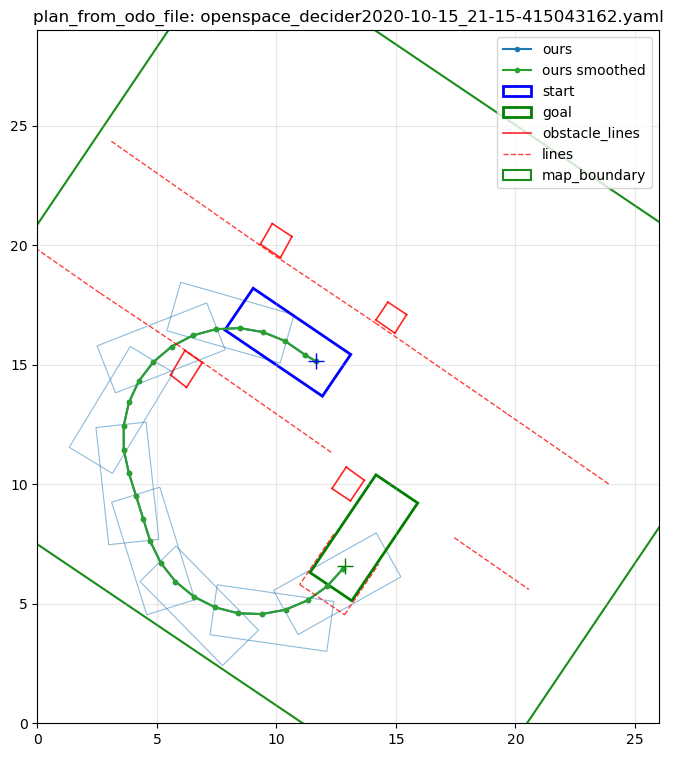

path points: 27, smoothed: 27


In [19]:
# run one case from DATA_DIR
cases = list_data0_cases
assert cases, f"no cases under {DATA_DIR}"
out = plan_from_odo_file(cases[1] if len(cases) > 1 else cases[0])
